In [4]:
import polars as pl
import string
import contractions
from wordcloud import WordCloud
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, pipeline
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [5]:
df = pl.read_csv('hf://datasets/visualcomments/human-human-conversations/select_dialog.csv', ignore_errors=True).drop_nans()

In [6]:
speech1 = df['speaker_1_speech'].cast(pl.Utf8)
speech2 = df['speaker_2_speech'].cast(pl.Utf8)

In [7]:
punctuation_replace = str.maketrans(string.punctuation, ' ' * len(string.punctuation))

df1 = [contractions.fix(row).lower().translate(punctuation_replace).split() for row in speech1]
df2 = [contractions.fix(row).lower().translate(punctuation_replace).split() for row in speech2]

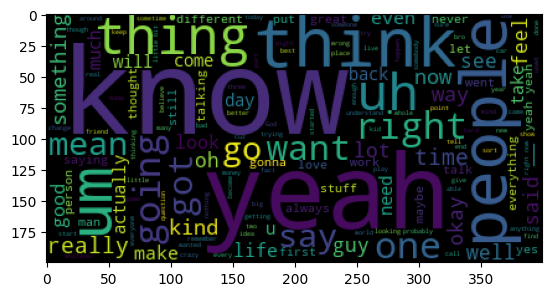

In [8]:
wordcloud = WordCloud().generate(' '.join(speech1))
plt.imshow(wordcloud)

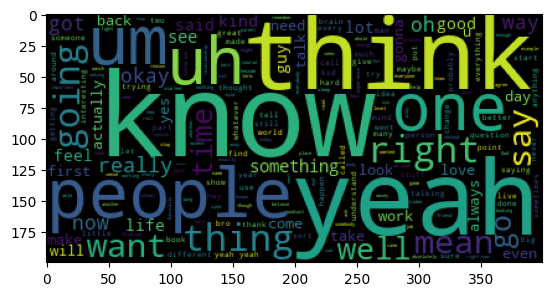

In [9]:
wordcloud = WordCloud().generate(' '.join(speech2))
plt.imshow(wordcloud)

In [10]:
emotion_analyzer = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

emotion_map = {
    "joy": 0, "love": 1, "surprise": 2, "neutral": 3, 
    "sadness": 4, "anger": 5, "fear": 6, "disgust": 7, "guilt": 8
}

emotions1 = np.zeros((len(speech1), len(emotion_map.keys())))
emotions2 = np.zeros((len(speech2), len(emotion_map.keys())))

curr_emotion1 = emotion_analyzer(speech1.to_list())
curr_emotion2 = emotion_analyzer(speech2.to_list())
    
for i in range(len(speech1)):
    for e in curr_emotion1[i]:
        label = e['label'].lower()
        if label in emotion_map:
            emotions1[i, emotion_map[label]] = e['score']

    for e in curr_emotion2[i]:
        label = e['label'].lower()
        if label in emotion_map:
            emotions2[i, emotion_map[label]] = e['score']

emotions1 = np.array(emotions1)
emotions2 = np.array(emotions2)

ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

In [ ]:
model = Sequential([
    Dense(emotions1.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(256, activation='relu'),
    Dropout(0.1),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dense(emotions2.shape[1], activation='sigmoid')
])
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(emotions1, emotions2, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)

(2164, 9) (2164, 9) (722, 9) (722, 9) (722, 9) (722, 9)


In [ ]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size = 32)

Epoch 1/50


In [51]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B")

tokenized1 = [tokenizer.encode(row) for row in speech1]
tokenized2 = [tokenizer.encode(row) for row in speech2]
tokenized1

[[18536, 11458],
 [67, 793, 1513, 944, 633, 35474, 705, 432, 39099],
 [35561, 9702, 498, 369, 3432, 752],
 [60793,
  1251,
  13083,
  429,
  429,
  594,
  537,
  1128,
  498,
  6723,
  504,
  279,
  3687,
  498,
  1414,
  279,
  3687,
  1035,
  3291,
  498,
  429,
  432,
  594,
  773,
  12473,
  650,
  60112,
  323,
  498,
  1414,
  498,
  2299,
  2581,
  2087,
  311,
  387,
  13942,
  10030,
  358,
  1744,
  429,
  594,
  264,
  17755,
  498,
  323,
  358,
  1414,
  5020,
  1632,
  21639,
  714,
  498,
  3960,
  1846,
  18366,
  323,
  498,
  653,
  2664,
  1091,
  1790,
  882,
  279,
  14317,
  16574,
  287,
  702,
  1012,
  6587,
  25165,
  10008,
  58916,
  323,
  12473,
  650,
  8653,
  1262,
  714,
  279,
  3033,
  702,
  1012,
  4633,
  432,
  5020,
  13919,
  323,
  582,
  2299,
  8491,
  4429,
  432,
  13919,
  304,
  7992,
  1632,
  358,
  2776,
  15713,
  498,
  1033,
  2952,
  311,
  633,
  700,
  1588],
 [285,
  429,
  979,
  498,
  2684,
  27493,
  498,
  3520,
  498,
  3